# Look at training set

(8, 1, 200, 200)


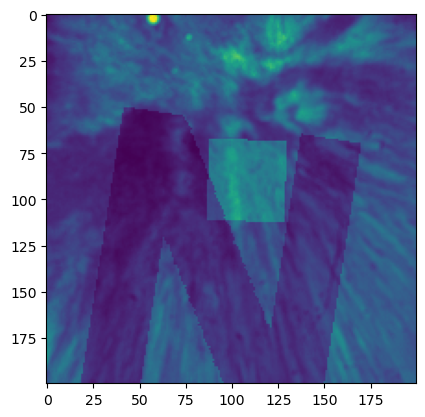

In [2]:
import numpy as np
import matplotlib.pyplot as plt

plot_id = 4

fo = np.load("./batch_example.npz")
X = fo["arr_0"]
Y = fo["arr_1"]
print(X.shape)
plt.imshow(X[plot_id,0])

# Look at validation set

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

fo = np.load("./ML_result/old/UNet_small_seed324y0.npz")
y_pred = fo["arr_0"]
y_test = fo["arr_1"]
X = fo["arr_2"]

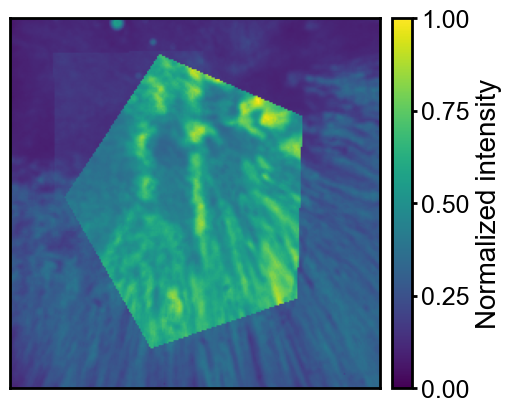

In [65]:
plot_idx = 9
plt.rcParams['font.sans-serif'] = ['Arial']
fig, ax = plt.subplots()

img = ax.imshow(X[plot_idx,0]/np.max(X[plot_idx,0]),
                vmax=1,vmin=0)
ax.set_xticks([])
ax.set_yticks([])

bwidth=2
plt.tick_params(which="major",width=bwidth,length=5)
plt.tick_params(which="minor",width=bwidth,length=3)
tk=plt.gca()
tk.spines["bottom"].set_linewidth(bwidth)
tk.spines["top"].set_linewidth(bwidth)
tk.spines["left"].set_linewidth(bwidth)
tk.spines["right"].set_linewidth(bwidth)

cax = fig.add_axes([ax.get_position().x1+0.02,ax.get_position().y0,0.03,ax.get_position().height])
cbar = fig.colorbar(img,cax=cax)
cbar.set_ticks([0,0.25,0.50,0.75,1.00])
cbar.set_label("Normalized intensity",fontsize=20)
cbar.outline.set_linewidth(2)
cbar.ax.tick_params(width=2,labelsize=18)
plt.show()

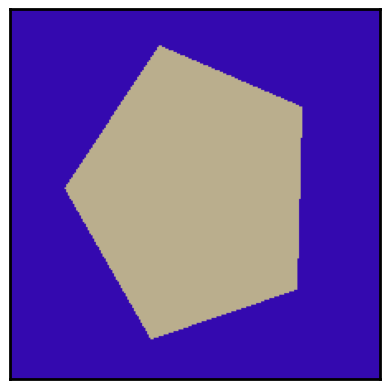

In [66]:
plt.imshow(np.transpose(y_test[plot_idx,:3],axes=(1,2,0)))
plt.xticks([])
plt.yticks([])
bwidth=2
plt.tick_params(which="major",width=bwidth,length=5)
plt.tick_params(which="minor",width=bwidth,length=3)
tk=plt.gca()
tk.spines["bottom"].set_linewidth(bwidth)
tk.spines["top"].set_linewidth(bwidth)
tk.spines["left"].set_linewidth(bwidth)
tk.spines["right"].set_linewidth(bwidth)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.014061689..0.84258604].


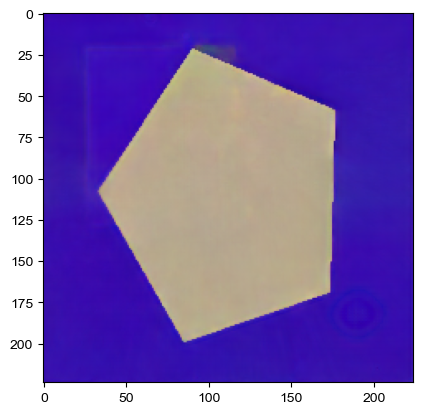

In [67]:
plt.imshow(np.transpose(y_pred[plot_idx,:3],axes=(1,2,0)))

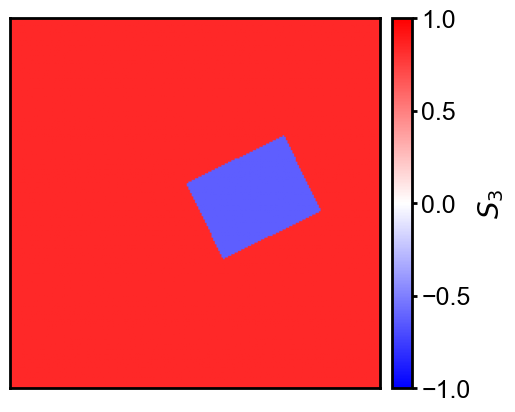

In [33]:
S_n = 3
plt.rcParams['font.sans-serif'] = ['Arial']
fig, ax = plt.subplots()

img = ax.imshow(y_test[plot_idx,2+S_n],
                    vmin=-1,vmax=1,cmap="bwr")
ax.set_xticks([])
ax.set_yticks([])

bwidth=2
plt.tick_params(which="major",width=bwidth,length=5)
plt.tick_params(which="minor",width=bwidth,length=3)
tk=plt.gca()
tk.spines["bottom"].set_linewidth(bwidth)
tk.spines["top"].set_linewidth(bwidth)
tk.spines["left"].set_linewidth(bwidth)
tk.spines["right"].set_linewidth(bwidth)

cax = fig.add_axes([ax.get_position().x1+0.02,ax.get_position().y0,0.03,ax.get_position().height])
cbar = fig.colorbar(img,cax=cax)
cbar.set_ticks([-1,-0.5,0,0.5,1])
cbar.set_label(r"$S_%d$"%S_n,fontsize=20)
cbar.outline.set_linewidth(2)
cbar.ax.tick_params(width=2,labelsize=18)
plt.show()

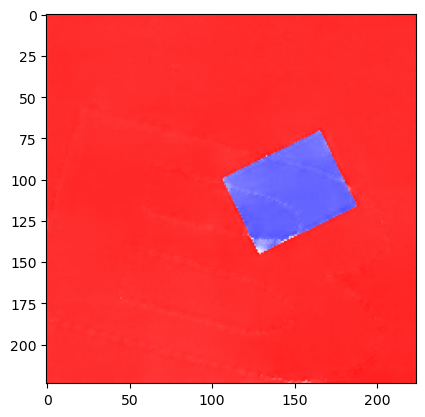

In [9]:
plt.imshow(y_pred[12,5],vmin=-1,vmax=1,cmap="bwr")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

fo = np.load("./ML_result/UNet_small_seed324y0.npz")
y_pred = fo["arr_0"]
y_test = fo["arr_1"]

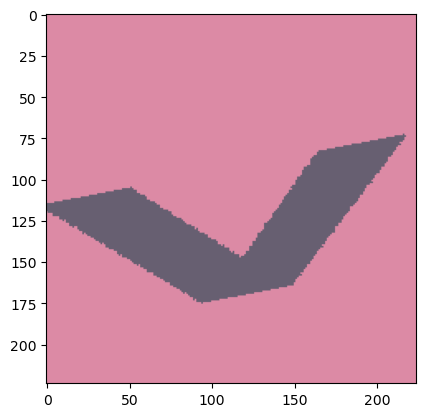

In [ ]:
plt.imshow(np.transpose(y_test[5,:3],axes=(1,2,0)))

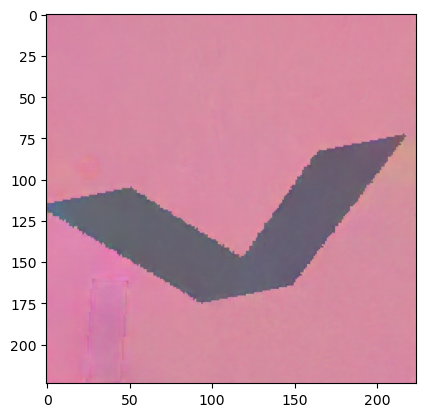

In [ ]:
plt.imshow(np.transpose(y_pred[5,:3],axes=(1,2,0)))

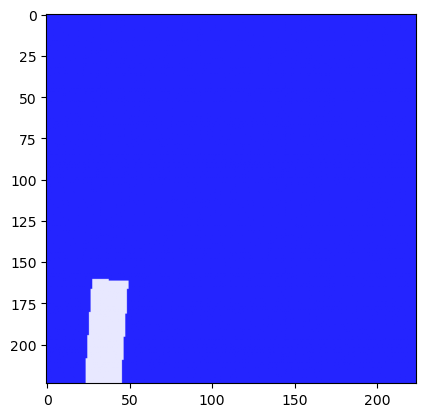

In [ ]:
plt.imshow(y_test[5,4],vmin=-1,vmax=1,cmap="bwr")

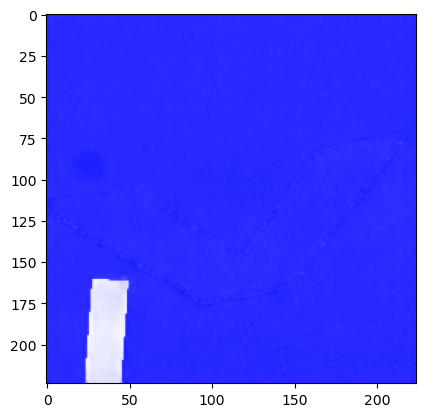

In [ ]:
plt.imshow(y_pred[5,4],vmin=-1,vmax=1,cmap="bwr")

# Test set

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from scipy.ndimage import zoom
import json

print("Using torch", torch.__version__)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

class DoubleConv(nn.Module):
    """(convolution => [BN] => ReLU) * 2"""

    def __init__(self, in_channels, out_channels, mid_channels=None):
        super().__init__()
        if not mid_channels:
            mid_channels = out_channels
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, mid_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(mid_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(mid_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)

class Down(nn.Module):
    """Downscaling with maxpool then double conv"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels)
        )

    def forward(self, x):
        return self.maxpool_conv(x)

class Up(nn.Module):
    """Upscaling then double conv"""
    def __init__(self, in_channels, out_channels, bilinear=True):
        super().__init__()

        # if bilinear, use the normal convolutions to reduce the number of channels
        if bilinear:
            self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
            self.conv = DoubleConv(in_channels, out_channels, in_channels // 2)
        else:
            self.up = nn.ConvTranspose2d(in_channels, in_channels // 2, kernel_size=2, stride=2)
            self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x1, x2):
        x1 = self.up(x1)
        # input is CHW
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]

        x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2,
                        diffY // 2, diffY - diffY // 2])
        # if you have padding issues, see
        # https://github.com/HaiyongJiang/U-Net-Pytorch-Unstructured-Buggy/commit/0e854509c2cea854e247a9c615f175f76fbb2e3a
        # https://github.com/xiaopeng-liao/Pytorch-UNet/commit/8ebac70e633bac59fc22bb5195e513d5832fb3bd
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)

class OutConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(OutConv, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, n_channels, n_classes, bilinear=False):
        super(UNet, self).__init__()
        self.n_channels = n_channels
        self.n_classes = n_classes
        self.bilinear = bilinear

        self.inc = (DoubleConv(n_channels, 64))
        self.down1 = (Down(64, 128))
        self.down2 = (Down(128, 256))
        self.down3 = (Down(256, 512))
        factor = 2 if bilinear else 1
        self.down4 = (Down(512, 1024 // factor))
        self.up1 = (Up(1024, 512 // factor, bilinear))
        self.up2 = (Up(512, 256 // factor, bilinear))
        self.up3 = (Up(256, 128 // factor, bilinear))
        self.up4 = (Up(128, 64, bilinear))
        self.outc = (OutConv(64, n_classes))

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        logits = self.outc(x)
        return logits

def get_x_test(namelist,config_file):
    with open(config_file,"r") as fo:
        config_dic = json.load(fo)
        norm_factor = config_dic["norm_factor"]
        HW = (config_dic["img_size"],config_dic["img_size"])
        cut_region = config_dic["cut_region"]
    result = np.zeros((len(namelist),1,HW[0],HW[1]),dtype=np.float32)
    for i in range(len(namelist)):
        fo = np.load(namelist[i])
        img = fo["arr_0"][cut_region[0]:cut_region[1],cut_region[2]:cut_region[3]]
        img = img/fo["arr_1"][0]/norm_factor
        img = zoom(img,(HW[0]/img.shape[0],HW[1]/img.shape[1]))
        result[i,0] = img.astype(np.float32)
    result = torch.from_numpy(result).to(device)
    return result
    
name_list = ["./images/glasses.npz","./images/glasses2.npz"]
config_file = "./ML_result/old/UNet_small_seed324.json"
x_test = get_x_test(name_list,config_file)
model = torch.load("./ML_result/old/UNet_small_seed324.pt",map_location="cpu").to(device)
model.eval()
with torch.no_grad():
    y_pred = model(x_test).detach().to("cpu").numpy()
x_test = x_test.to("cpu").numpy()
y_pred[:,:3] = np.where(y_pred[:,:3]<0,0,y_pred[:,:3])
print("Finished...")

Using torch 2.5.1
Using device: cpu


/var/folders/dx/ypjj7qg52dg6jk1ct493lg2c0000gn/T/ipykernel_12184/3529162073.py:129: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load("./ML_result/old/UNet_sm

Finished...


0.00017187500000000002


([], [])

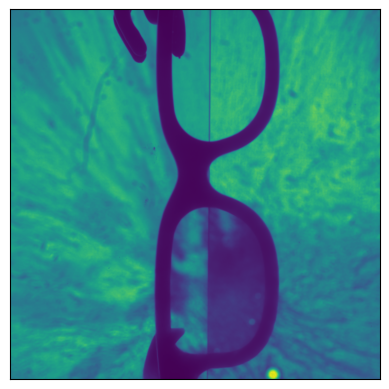

In [6]:
import matplotlib.pyplot as plt
import numpy as np

fo = np.load("./images/glasses2.npz")
img = fo["arr_0"][50:1150,450:1550]/fo["arr_1"][0]/3
plt.imshow(img[::-1,::-1])
print(img[600,550])
np.mean(img[590:610,540:560]),np.std(img[590:610,540:560])
plt.xticks([])
plt.yticks([])

(2.539092953684573e-05, 8.097857236606746e-05)

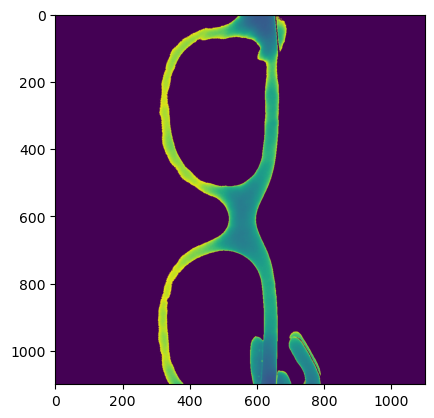

In [7]:
mask = np.where(img<0.0004,1,0)
plt.imshow(img*mask)
np.mean(img*mask),np.std(img*mask)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.1136764].


(3, 224, 224)


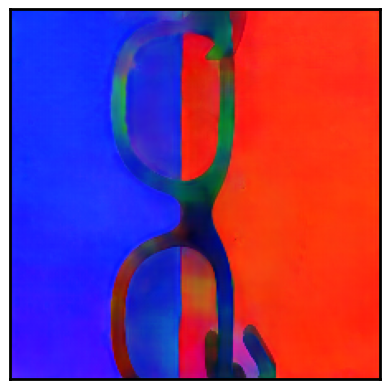

In [8]:
plt.imshow(np.transpose(y_pred[1,:3],axes=(1,2,0)))
plt.xticks([])
plt.yticks([])
bwidth=2
plt.tick_params(which="major",width=bwidth,length=5)
plt.tick_params(which="minor",width=bwidth,length=3)
tk=plt.gca()
tk.spines["bottom"].set_linewidth(bwidth)
tk.spines["top"].set_linewidth(bwidth)
tk.spines["left"].set_linewidth(bwidth)
tk.spines["right"].set_linewidth(bwidth)
plt.savefig("./CD.svg",transparent=True,bbox_inches="tight")
print(y_pred[1,:3].shape)
plt.show()

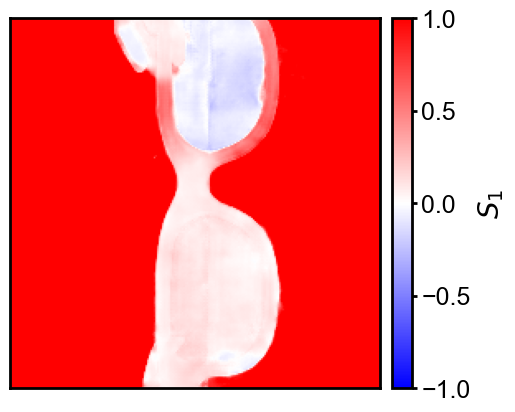

In [9]:
from cmcrameri import cm


plt.rcParams['font.sans-serif'] = ['Arial']
fig, ax = plt.subplots()

cur_img = y_pred[1,3]*np.sum(y_pred[1,:3],0)
img = ax.imshow(cur_img[::-1,::-1],vmin=-1,vmax=1,cmap="bwr")
plt.xticks([])
plt.yticks([])

bwidth=2
plt.tick_params(which="major",width=bwidth,length=5)
plt.tick_params(which="minor",width=bwidth,length=3)
tk=plt.gca()
tk.spines["bottom"].set_linewidth(bwidth)
tk.spines["top"].set_linewidth(bwidth)
tk.spines["left"].set_linewidth(bwidth)
tk.spines["right"].set_linewidth(bwidth)

cax = fig.add_axes([ax.get_position().x1+0.02,ax.get_position().y0,0.03,ax.get_position().height])
cbar = fig.colorbar(img,cax=cax)
cbar.set_ticks([-1.0,-0.5,0.0,0.5,1.0])
cbar.set_label("$S_1$",fontsize=20)
cbar.outline.set_linewidth(2)
cbar.ax.tick_params(width=2,labelsize=18)
plt.savefig("S1.png",dpi=300,transparent=True)
plt.show()

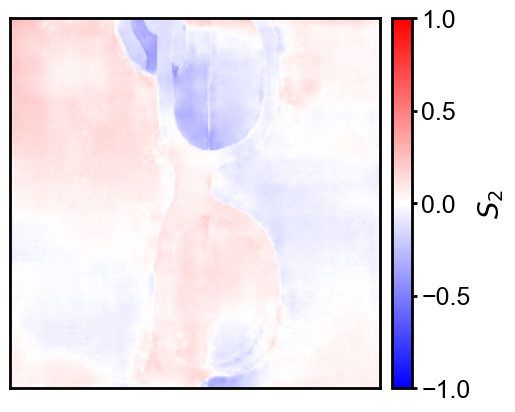

In [10]:
plt.rcParams['font.sans-serif'] = ['Arial']
fig, ax = plt.subplots()

cur_img = y_pred[1,4]*np.sum(y_pred[1,:3],0)
img = ax.imshow(cur_img[::-1,::-1],vmin=-1,vmax=1,cmap="bwr")
plt.xticks([])
plt.yticks([])

bwidth=2
plt.tick_params(which="major",width=bwidth,length=5)
plt.tick_params(which="minor",width=bwidth,length=3)
tk=plt.gca()
tk.spines["bottom"].set_linewidth(bwidth)
tk.spines["top"].set_linewidth(bwidth)
tk.spines["left"].set_linewidth(bwidth)
tk.spines["right"].set_linewidth(bwidth)

cax = fig.add_axes([ax.get_position().x1+0.02,ax.get_position().y0,0.03,ax.get_position().height])
cbar = fig.colorbar(img,cax=cax)
cbar.set_ticks([-1.0,-0.5,0.0,0.5,1.0])
cbar.set_label("$S_2$",fontsize=20)
cbar.outline.set_linewidth(2)
cbar.ax.tick_params(width=2,labelsize=18)
plt.savefig("S2.png",dpi=300,transparent=True)
plt.show()

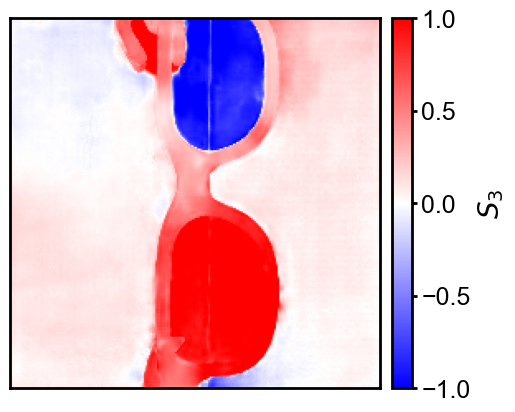

In [11]:
plt.rcParams['font.sans-serif'] = ['Arial']
fig, ax = plt.subplots()

cur_img = y_pred[1,5]*np.sum(y_pred[1,:3],0)
img = ax.imshow(cur_img[::-1,::-1],vmin=-1,vmax=1,cmap="bwr")
plt.xticks([])
plt.yticks([])

bwidth=2
plt.tick_params(which="major",width=bwidth,length=5)
plt.tick_params(which="minor",width=bwidth,length=3)
tk=plt.gca()
tk.spines["bottom"].set_linewidth(bwidth)
tk.spines["top"].set_linewidth(bwidth)
tk.spines["left"].set_linewidth(bwidth)
tk.spines["right"].set_linewidth(bwidth)

cax = fig.add_axes([ax.get_position().x1+0.02,ax.get_position().y0,0.03,ax.get_position().height])
cbar = fig.colorbar(img,cax=cax)
cbar.set_ticks([-1.0,-0.5,0.0,0.5,1.0])
cbar.set_label("$S_3$",fontsize=20)
cbar.outline.set_linewidth(2)
cbar.ax.tick_params(width=2,labelsize=18)
plt.savefig("S3.png",dpi=300,transparent=True)
plt.show()